# TensorFlow/Keras로 딥러닝 최적화 함수 비교 실습

이 노트북은 같은 데이터셋과 같은 신경망 구조를 사용하여 여러 최적화 함수의 학습 결과를 비교한다.

비교할 최적화 함수는 다음과 같다.

- SGD
- SGD + Momentum
- RMSprop
- Adam
- AdamW

실습 목표는 최적화 함수가 바뀌면 손실값과 정확도 변화가 어떻게 달라지는지 확인하는 것이다.


## 1. 라이브러리 불러오기

TensorFlow/Keras로 모델을 만들고, scikit-learn으로 간단한 분류 데이터셋을 생성한다.


In [1]:
# tensorflow는 딥러닝 모델 생성, 학습, 평가에 사용하는 대표적인 라이브러리이다.
import tensorflow as tf

# keras는 TensorFlow 안에서 신경망 모델을 쉽게 구성할 수 있게 해주는 고수준 API이다.
from tensorflow import keras

# layers는 Dense, Input 같은 신경망 계층을 만들 때 사용한다.
from tensorflow.keras import layers

# make_moons는 두 개의 초승달 모양 클래스를 가진 비선형 분류 데이터셋을 생성한다.
from sklearn.datasets import make_moons

# train_test_split은 데이터를 학습용 데이터와 테스트용 데이터로 나누기 위해 사용한다.
from sklearn.model_selection import train_test_split

# StandardScaler는 입력 특성의 평균을 0, 표준편차를 1에 가깝게 표준화하기 위해 사용한다.
from sklearn.preprocessing import StandardScaler

# numpy는 배열 계산과 난수 고정에 사용한다.
import numpy as np

# pandas는 최적화 함수별 결과를 표 형태로 정리하기 위해 사용한다.
import pandas as pd

# matplotlib.pyplot은 손실값과 정확도 그래프를 그리기 위해 사용한다.
import matplotlib.pyplot as plt

# random은 파이썬 기본 난수 생성을 고정하기 위해 사용한다.
import random


## 2. 실행 결과를 일정하게 만들기 위한 난수 고정

딥러닝은 가중치 초기화와 데이터 섞기 과정에서 난수가 사용된다.  
매번 결과가 크게 달라지지 않도록 seed 값을 고정한다.


In [2]:
# seed는 난수 생성 결과를 고정하기 위한 기준 숫자이다.
seed = 42

# 파이썬 random 모듈의 난수 생성 기준을 고정한다.
random.seed(seed)

# numpy의 난수 생성 기준을 고정한다.
np.random.seed(seed)

# TensorFlow의 난수 생성 기준을 고정한다.
tf.random.set_seed(seed)

# 현재 TensorFlow 버전을 출력한다.
print("TensorFlow version:", tf.__version__)


TensorFlow version: 2.20.0


## 3. 데이터셋 생성 및 전처리

최적화 함수 차이를 확인하기 위해 직선 하나로는 쉽게 나눌 수 없는 `make_moons` 데이터셋을 사용한다.


In [3]:
# make_moons 함수로 샘플 2000개짜리 이진 분류 데이터셋을 생성한다.
X, y = make_moons(n_samples=2000, noise=0.25, random_state=seed)

# train_test_split으로 전체 데이터를 학습용 80%, 테스트용 20%로 나눈다.
X_train, X_test, y_train, y_test = train_test_split(
    X,                  # 입력 데이터 전체를 전달한다.
    y,                  # 정답 라벨 전체를 전달한다.
    test_size=0.2,      # 전체 데이터 중 20%를 테스트 데이터로 사용한다.
    random_state=seed,  # 데이터를 나누는 난수 기준을 고정한다.
    stratify=y          # 클래스 비율이 학습/테스트 데이터에서 비슷하게 유지되도록 한다.
)

# StandardScaler 객체를 생성하여 입력 데이터의 스케일을 맞출 준비를 한다.
scaler = StandardScaler()

# 학습 데이터 기준으로 평균과 표준편차를 계산하고, 학습 데이터를 표준화한다.
X_train = scaler.fit_transform(X_train)

# 테스트 데이터는 학습 데이터에서 계산된 평균과 표준편차를 그대로 사용하여 표준화한다.
X_test = scaler.transform(X_test)

# TensorFlow 학습에 적합하도록 학습 입력 데이터를 float32 자료형으로 변환한다.
X_train = X_train.astype("float32")

# TensorFlow 학습에 적합하도록 테스트 입력 데이터를 float32 자료형으로 변환한다.
X_test = X_test.astype("float32")

# 정답 데이터는 sparse_categorical_crossentropy에서 사용할 수 있도록 정수형으로 유지한다.
y_train = y_train.astype("int32")

# 테스트 정답 데이터도 정수형으로 유지한다.
y_test = y_test.astype("int32")

# 입력 데이터의 모양을 출력하여 특성 수가 2개인지 확인한다.
print("X_train shape:", X_train.shape)

# 정답 데이터의 클래스 종류를 출력하여 이진 분류 문제인지 확인한다.
print("classes:", np.unique(y_train))


X_train shape: (1600, 2)
classes: [0 1]


## 4. MLP 모델 생성 함수

동일한 모델 구조에서 최적화 함수만 바꾸어 비교한다.


In [4]:
# build_model 함수는 새로운 Keras MLP 모델을 생성한다.
def build_model():
    # Sequential은 계층을 순서대로 쌓아 만드는 가장 간단한 Keras 모델 방식이다.
    model = keras.Sequential([
        # Input 계층은 입력 데이터의 특성 개수가 2개임을 모델에 알려준다.
        layers.Input(shape=(2,)),

        # 첫 번째 Dense 계층은 입력 특성 2개를 은닉 노드 16개로 변환한다.
        layers.Dense(16, activation="relu"),

        # 두 번째 Dense 계층은 은닉 노드 16개를 다시 은닉 노드 16개로 변환한다.
        layers.Dense(16, activation="relu"),

        # 마지막 Dense 계층은 클래스 2개의 점수를 출력한다.
        layers.Dense(2, activation="softmax")
    ])

    # 생성한 모델 객체를 반환한다.
    return model


## 5. Optimizer 생성 함수

같은 모델에 대해 최적화 함수만 바꿔 실험할 수 있도록 함수로 만든다.


In [5]:
# get_optimizer 함수는 optimizer_name에 따라 서로 다른 Keras 최적화 함수를 생성한다.
def get_optimizer(optimizer_name):
    # optimizer_name이 "SGD"이면 기본 SGD 최적화 함수를 사용한다.
    if optimizer_name == "SGD":
        # SGD는 가장 기본적인 경사하강법 계열 최적화 함수이다.
        return keras.optimizers.SGD(learning_rate=0.01)

    # optimizer_name이 "SGD_Momentum"이면 Momentum이 추가된 SGD를 사용한다.
    elif optimizer_name == "SGD_Momentum":
        # momentum=0.9는 이전 업데이트 방향을 90% 정도 반영하겠다는 의미이다.
        return keras.optimizers.SGD(learning_rate=0.01, momentum=0.9)

    # optimizer_name이 "RMSprop"이면 RMSprop 최적화 함수를 사용한다.
    elif optimizer_name == "RMSprop":
        # RMSprop은 파라미터별로 학습률을 조정하여 학습을 안정화한다.
        return keras.optimizers.RMSprop(learning_rate=0.001)

    # optimizer_name이 "Adam"이면 Adam 최적화 함수를 사용한다.
    elif optimizer_name == "Adam":
        # Adam은 Momentum과 RMSprop의 아이디어를 결합한 대표적인 최적화 함수이다.
        return keras.optimizers.Adam(learning_rate=0.001)

    # optimizer_name이 "AdamW"이면 AdamW 최적화 함수를 사용한다.
    elif optimizer_name == "AdamW":
        # AdamW는 Adam에 weight_decay를 더 올바른 방식으로 적용하여 과적합을 줄이는 데 도움을 준다.
        return keras.optimizers.AdamW(learning_rate=0.001, weight_decay=0.01)

    # 위 조건에 없는 이름이 들어오면 오류를 발생시킨다.
    else:
        # 사용자가 잘못된 최적화 함수 이름을 넣었음을 알려준다.
        raise ValueError("지원하지 않는 optimizer_name입니다.")


## 6. 학습 함수 정의

하나의 최적화 함수에 대해 모델을 학습시키고, epoch별 손실값과 정확도를 저장한다.


In [6]:
# train_one_optimizer 함수는 하나의 최적화 함수로 모델을 학습하고 결과를 반환한다.
def train_one_optimizer(optimizer_name, epochs=50):
    # 매 실험마다 같은 초기 가중치에서 시작하도록 TensorFlow seed를 다시 고정한다.
    tf.random.set_seed(seed)

    # 새로운 MLP 모델을 생성한다.
    model = build_model()

    # optimizer_name에 해당하는 최적화 함수를 생성한다.
    optimizer = get_optimizer(optimizer_name)

    # 모델의 학습 방식, 손실 함수, 평가지표를 설정한다.
    model.compile(
        optimizer=optimizer,                              # 현재 실험에서 사용할 최적화 함수를 지정한다.
        loss="sparse_categorical_crossentropy",           # 정답이 정수 라벨일 때 사용하는 다중 분류 손실 함수이다.
        metrics=["accuracy"]                              # 학습 중 정확도를 함께 계산하도록 설정한다.
    )

    # 모델을 학습한다.
    history = model.fit(
        X_train,                                          # 학습 입력 데이터를 전달한다.
        y_train,                                          # 학습 정답 데이터를 전달한다.
        validation_data=(X_test, y_test),                 # 각 epoch마다 테스트 데이터의 손실과 정확도를 계산한다.
        epochs=epochs,                                    # 전체 학습 반복 횟수를 지정한다.
        batch_size=32,                                    # 한 번에 32개 데이터씩 묶어서 학습한다.
        verbose=0                                         # 학습 로그를 길게 출력하지 않도록 설정한다.
    )

    # 학습이 끝난 후 테스트 데이터로 최종 손실값과 정확도를 계산한다.
    test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)

    # 최적화 함수 이름, 최종 손실값, 최종 정확도를 출력한다.
    print(f"{optimizer_name:12s} | Final Loss: {test_loss:.4f} | Final Test Acc: {test_acc:.4f}")

    # 학습 기록과 최종 모델을 반환한다.
    return history, model


## 7. 여러 최적화 함수 학습 실행

같은 데이터와 같은 모델 구조에서 최적화 함수만 바꾸어 학습한다.


In [7]:
# 비교할 최적화 함수 이름 목록을 만든다.
optimizer_names = ["SGD", "SGD_Momentum", "RMSprop", "Adam", "AdamW"]

# 각 최적화 함수별 학습 결과를 저장할 딕셔너리를 생성한다.
results = {}

# optimizer_names에 들어 있는 최적화 함수를 하나씩 반복한다.
for optimizer_name in optimizer_names:
    # 현재 어떤 최적화 함수를 학습하는지 출력한다.
    print("\n학습 시작:", optimizer_name)

    # 현재 최적화 함수로 모델을 학습하고 결과를 받는다.
    history, model = train_one_optimizer(optimizer_name, epochs=50)

    # 현재 최적화 함수의 학습 기록과 모델을 딕셔너리에 저장한다.
    results[optimizer_name] = {
        "history": history,
        "model": model
    }



학습 시작: SGD
SGD          | Final Loss: 0.2771 | Final Test Acc: 0.8850

학습 시작: SGD_Momentum
SGD_Momentum | Final Loss: 0.1802 | Final Test Acc: 0.9250

학습 시작: RMSprop
RMSprop      | Final Loss: 0.1738 | Final Test Acc: 0.9250

학습 시작: Adam
Adam         | Final Loss: 0.1697 | Final Test Acc: 0.9275

학습 시작: AdamW
AdamW        | Final Loss: 0.1712 | Final Test Acc: 0.9300


## 8. 최종 결과 표로 확인

최적화 함수별 마지막 손실값과 마지막 정확도를 비교한다.


In [8]:
# 결과 표에 들어갈 행 데이터를 저장할 빈 리스트를 만든다.
summary_rows = []

# results 딕셔너리에서 최적화 함수 이름과 결과를 하나씩 꺼낸다.
for optimizer_name, result in results.items():
    # Keras history 객체에서 검증 손실 기록을 가져온다.
    val_loss_history = result["history"].history["val_loss"]

    # Keras history 객체에서 검증 정확도 기록을 가져온다.
    val_acc_history = result["history"].history["val_accuracy"]

    # 현재 최적화 함수의 최종 검증 손실값과 최종 검증 정확도를 하나의 딕셔너리로 정리한다.
    summary_rows.append({
        "Optimizer": optimizer_name,
        "Final Validation Loss": val_loss_history[-1],
        "Final Validation Accuracy": val_acc_history[-1]
    })

# 리스트 형태의 결과를 pandas DataFrame으로 변환한다.
summary_df = pd.DataFrame(summary_rows)

# 정확도가 높은 순서로 결과 표를 정렬한다.
summary_df = summary_df.sort_values(by="Final Validation Accuracy", ascending=False)

# 정리된 결과 표를 출력한다.
summary_df


,Optimizer,Final Validation Loss,Final Validation Accuracy
4,AdamW,0.171209,0.9300
3,Adam,0.169679,0.9275
2,RMSprop,0.173849,0.9250
1,SGD_Momentum,0.180223,0.9250
0,SGD,0.277057,0.8850


## 9. 손실값 변화 그래프

손실값이 빠르게 낮아질수록 해당 최적화 함수가 이 실험에서 빠르게 학습했다는 의미로 볼 수 있다.


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 48324 (\N{HANGUL SYLLABLE BYEOL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 48320 (\N{HANGUL SYLLABLE BYEON}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 54868 (\N{HANGUL SYLLABLE HWA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


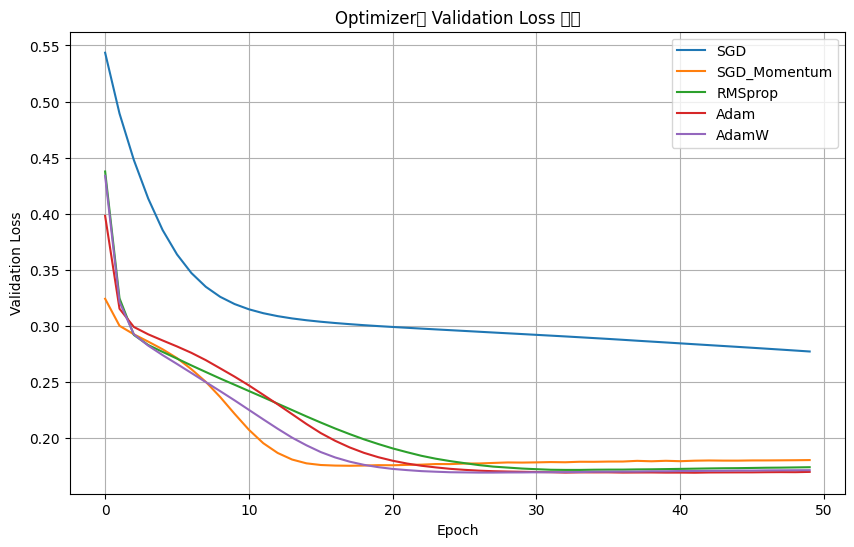

In [9]:
# 그래프 크기를 가로 10, 세로 6으로 설정한다.
plt.figure(figsize=(10, 6))

# 각 최적화 함수별 검증 손실 기록을 그래프에 그린다.
for optimizer_name, result in results.items():
    # history 객체에서 검증 손실 기록을 가져온다.
    val_loss = result["history"].history["val_loss"]

    # x축은 epoch, y축은 검증 손실값이 되도록 선 그래프를 그린다.
    plt.plot(val_loss, label=optimizer_name)

# 그래프 제목을 설정한다.
plt.title("Optimizer별 Validation Loss 변화")

# x축 이름을 설정한다.
plt.xlabel("Epoch")

# y축 이름을 설정한다.
plt.ylabel("Validation Loss")

# 각 선이 어떤 최적화 함수인지 보여주는 범례를 표시한다.
plt.legend()

# 그래프 격자선을 표시하여 값을 읽기 쉽게 만든다.
plt.grid(True)

# 그래프를 화면에 출력한다.
plt.show()


## 10. 정확도 변화 그래프

정확도가 빠르게 올라가고 안정적으로 유지되는 최적화 함수가 좋은 결과를 보인 것이다.


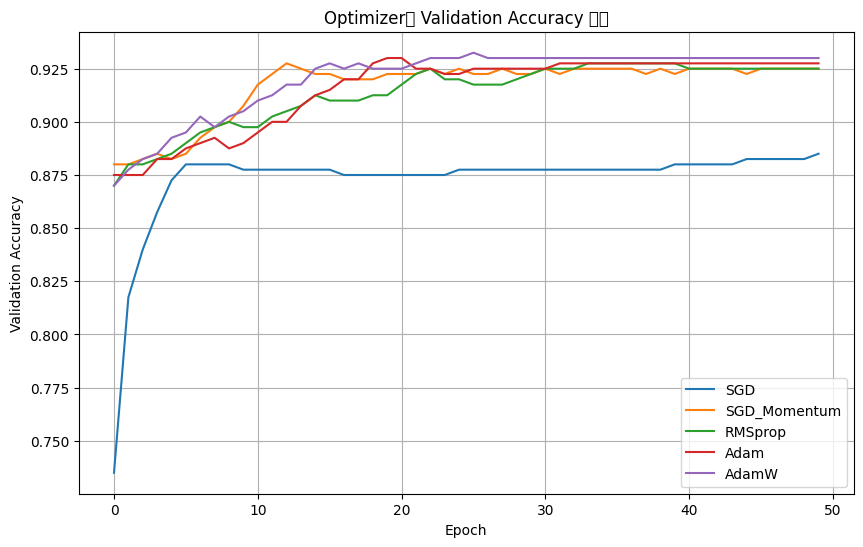

In [10]:
# 그래프 크기를 가로 10, 세로 6으로 설정한다.
plt.figure(figsize=(10, 6))

# 각 최적화 함수별 검증 정확도 기록을 그래프에 그린다.
for optimizer_name, result in results.items():
    # history 객체에서 검증 정확도 기록을 가져온다.
    val_accuracy = result["history"].history["val_accuracy"]

    # x축은 epoch, y축은 검증 정확도가 되도록 선 그래프를 그린다.
    plt.plot(val_accuracy, label=optimizer_name)

# 그래프 제목을 설정한다.
plt.title("Optimizer별 Validation Accuracy 변화")

# x축 이름을 설정한다.
plt.xlabel("Epoch")

# y축 이름을 설정한다.
plt.ylabel("Validation Accuracy")

# 각 선이 어떤 최적화 함수인지 보여주는 범례를 표시한다.
plt.legend()

# 그래프 격자선을 표시하여 값을 읽기 쉽게 만든다.
plt.grid(True)

# 그래프를 화면에 출력한다.
plt.show()


## 11. 실습 해석

일반적으로 Adam과 AdamW는 초반 학습 속도가 빠르게 나타나는 경우가 많다.  
SGD는 단순하지만 학습률 설정에 민감하고, Momentum을 추가하면 더 안정적으로 이동할 수 있다.  
RMSprop은 파라미터별 학습률을 조정하므로 단순 SGD보다 안정적인 경우가 많다.

단, 어떤 최적화 함수가 항상 최고라는 뜻은 아니다.  
데이터셋, 모델 구조, 학습률, 배치 크기, epoch 수에 따라 결과는 달라질 수 있다.
